In [1]:
import numpy as np

from weather.config import (
    Experiment,
    WeatherFixedParams,
    WeatherGridParams,
    MLPFixedParams,
    MLPGridParams,
    FitFixedParams,
    FitGridParams,
)

from weather.search import Search

from mlp.utils import (
    plot_loss,
    regression_report,
    classification_report_binary,
    plot_roc_auc,
    plot_accuracy,
    accuracy_within_tolerance,
)


In [2]:
SEED = 42
np.random.seed(SEED)


In [3]:
# =========================================================
# 1) TEMPERATURE REGRESSION
# =========================================================
exp_temp_encoding = Experiment(
    name="temperature_regression_encoding",

    # =========================
    # WEATHER
    # =========================
    weather_fixed=WeatherFixedParams(
        target="temperature",
        target_mode="regression",
        # target_threshold=6.0,
        data_dir="../data",
        skip_day=True,
        # normalization="global",
        encode_wind_direction=True,
    ),

    weather_grid=WeatherGridParams(
        window_aggregation=["flatten"],
        # window_aggregation=["flatten", "aggregate"],
        window_size=3,
        normalization=["standardize"],
        # normalization=["standardize", "minmax", "l2", "none"],
        input_variables=[
            ("temperature",),
            ("temperature", "humidity"),
            # ("temperature", "humidity", "pressure"),
            # ("temperature", "humidity", "pressure", "wind_speed"),
            # ("temperature", "humidity", "pressure", "wind_speed", "wind_direction"),
        ],
        aggregations=[{
            "temperature": ("mean", "min", "max"),
            "humidity": ("mean", "min", "max"),
            "pressure": ("mean", "min", "max"),
            "wind_speed": ("mean", "max"),
            "wind_direction": ("mean",),
        },
        {
            "temperature": ("mean", "min", "max", "trend"),
            "humidity": ("mean", "min", "max", "trend"),
            "pressure": ("mean", "min", "max", "trend"),
            "wind_speed": ("mean", "max"),
            "wind_direction": ("mean",),
        }],
        cities=("Vancouver",),
    ),

    # =========================
    # MLP
    # =========================
    mlp_fixed=MLPFixedParams(
        task="regression",
        beta = 0.9,
        beta2 = 0.999,
        eps = 1e-8,
        adaptive_lr=True,
        lr_decay=0.99,
    ),

    mlp_grid=MLPGridParams(
        hidden_layers=[(32, 64)],
        loss=["huber"],
        activation=["gelu"],
        learning_rate=0.01,
        seed=SEED,
        use_bias=True,
        optimizer="momentum",
    ),

    # =========================
    # FIT
    # =========================
    fit_fixed=FitFixedParams(
        verbose=True,
        log_every=None,
        use_tqdm=True,
        one_hot_if_needed=True,
        early_stopping=True,
        patience=50,
        min_delta=0.0001,
    ),

    fit_grid=FitGridParams(
        epochs=400,
        batch_size="auto",
        shuffle=False,
        val_split=0.1,
    ),
)

# =========================================================
# 2) WIND (>=6 m/s) BINARY CLASSIFICATION
# =========================================================
exp_wind_encoding = Experiment(
    name="wind6_binary_encoding",

    # =========================
    # WEATHER
    # =========================
    weather_fixed=WeatherFixedParams(
        target="wind_speed",
        target_mode="binary",
        target_threshold=6.0,
        data_dir="../data",
        skip_day=True,
        # normalization="global",
        encode_wind_direction=True,
    ),

    weather_grid=WeatherGridParams(
        window_aggregation=["flatten", "aggregate"],
        window_size=[2, 3, 4],
        normalization=["standardize", "minmax", "l2", "none"],
        input_variables=[
            ("wind_speed"),
            ("wind_speed", "wind_direction"),
            ("wind_speed", "wind_direction", "pressure"),
            ("wind_speed", "wind_direction", "pressure", "humidity"),
            ("wind_speed", "wind_direction", "pressure", "humidity", "temperature"),
        ],
        aggregations=[{
            "temperature": ("mean", "min", "max"),
            "humidity": ("mean", "min", "max"),
            "pressure": ("mean", "min", "max"),
            "wind_speed": ("mean", "max"),
            "wind_direction": ("mean",),
        },
        {
            "temperature": ("mean", "min", "max", "trend"),
            "humidity": ("mean", "min", "max", "trend"),
            "pressure": ("mean", "min", "max", "trend"),
            "wind_speed": ("mean", "max"),
            "wind_direction": ("mean",),
        }],
        cities=[
            ("Vancouver",),
            # ("Vancouver", "Seattle", "Portland"),
            # ("Beersheba", "Tel Aviv District", "Eilat", "Haifa", "Nahariyya", "Jerusalem")
        ]
    ),

    # =========================
    # MLP
    # =========================
    mlp_fixed=MLPFixedParams(
        task="binary",
        beta = 0.9,
        beta2 = 0.999,
        eps = 1e-8,
        adaptive_lr=True,
        lr_decay=0.99,
    ),

    mlp_grid=MLPGridParams(
        hidden_layers=[(32, 64)],
        loss=["binary_cross_entropy"],
        activation=["gelu"],
        learning_rate=0.01,
        seed=SEED,
        use_bias=True,
        optimizer="momentum",
    ),

    # =========================
    # FIT
    # =========================
    fit_fixed=FitFixedParams(
        verbose=True,
        log_every=None,
        use_tqdm=True,
        one_hot_if_needed=True,
        early_stopping=True,
        patience=50,
        min_delta=0.0001,
    ),

    fit_grid=FitGridParams(
        epochs=400,
        batch_size="auto",
        shuffle=False,
        val_split=0.1,
    ),
)

experiments = [exp_temp_encoding, exp_wind_encoding]


In [4]:
# %pdb on

search = Search()

results = search.run(exp_temp_encoding)

# %pdb off



Starting experiment: temperature_regression_encoding

Building dataset
  → TRAIN split


Vancouver | windows: 100%|██████████| 1518/1518 [00:02<00:00, 630.07it/s]


  → TEST split


Vancouver | windows: 100%|██████████| 361/361 [00:00<00:00, 691.16it/s]



Configuration run #1:
WEATHER (variable):
  - window_aggregation: flatten
  - input_variables: ('temperature',)
  - aggregations: {'temperature': ('mean', 'min', 'max'), 'humidity': ('mean', 'min', 'max'), 'pressure': ('mean', 'min', 'max'), 'wind_speed': ('mean', 'max'), 'wind_direction': ('mean',)}
  - normalization: standardize
MLP (variable):
  - hidden_layers: (32, 64)
  - loss: huber
  - activation: gelu

Training model


...

  → TEST split


Vancouver | windows: 100%|██████████| 361/361 [00:01<00:00, 280.44it/s]



Configuration run #4:
WEATHER (variable):
  - window_aggregation: flatten
  - input_variables: ('temperature', 'humidity')
  - aggregations: {'temperature': ('mean', 'min', 'max', 'trend'), 'humidity': ('mean', 'min', 'max', 'trend'), 'pressure': ('mean', 'min', 'max', 'trend'), 'wind_speed': ('mean', 'max'), 'wind_direction': ('mean',)}
  - normalization: standardize
MLP (variable):
  - hidden_layers: (32, 64)
  - loss: huber
  - activation: gelu

Training model


Training:  48%|████▊     | 192/400 [00:03<00:04, 49.06it/s, acc=n/a, loss=1.1824, lr=0.00145197] 

Early stopping at epoch 193, best val_loss=1.364965 after 50 epochs without improvement.
Training finished in 3.92 seconds

Experiment finished | total runs = 4





EXPERIMENT: temperature_regression_encoding
TASK: REGRESSION
CONFIGURATION (variable params):
  WEATHER:
    - window_aggregation: flatten
    - input_variables: ('temperature',)
    - aggregations: {'temperature': ('mean', 'min', 'max'), 'humidity': ('mean', 'min', 'max'), 'pressure': ('mean', 'min', 'max'), 'wind_speed': ('mean', 'max'), 'wind_direction': ('mean',)}
    - normalization: standardize
  MLP:
    - hidden_layers: (32, 64)
    - loss: huber
    - activation: gelu
--------------------------------------------------------------------------------
=== TEST METRICS (REGRESSION) ===
MAE              : 1.9234
MSE              : 6.4342
RMSE             : 2.5366
Accuracy |err|≤2°C   : 0.6189
Accuracy |err|≤2.5°C : 0.7195


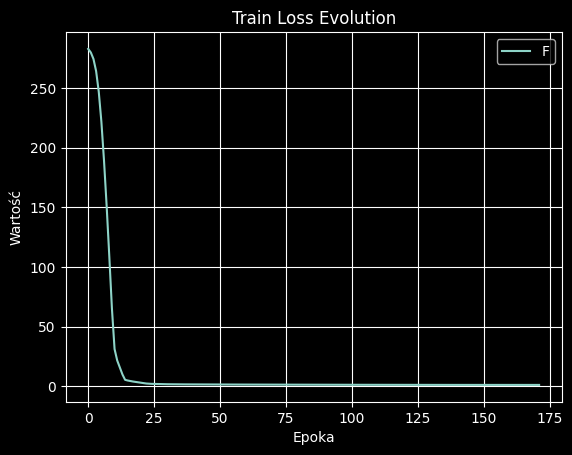



EXPERIMENT: temperature_regression_encoding
TASK: REGRESSION
CONFIGURATION (variable params):
  WEATHER:
    - window_aggregation: flatten
    - input_variables: ('temperature',)
    - aggregations: {'temperature': ('mean', 'min', 'max', 'trend'), 'humidity': ('mean', 'min', 'max', 'trend'), 'pressure': ('mean', 'min', 'max', 'trend'), 'wind_speed': ('mean', 'max'), 'wind_direction': ('mean',)}
    - normalization: standardize
  MLP:
    - hidden_layers: (32, 64)
    - loss: huber
    - activation: gelu
--------------------------------------------------------------------------------
=== TEST METRICS (REGRESSION) ===
MAE              : 1.9701
MSE              : 6.8018
RMSE             : 2.6080
Accuracy |err|≤2°C   : 0.6006
Accuracy |err|≤2.5°C : 0.7104


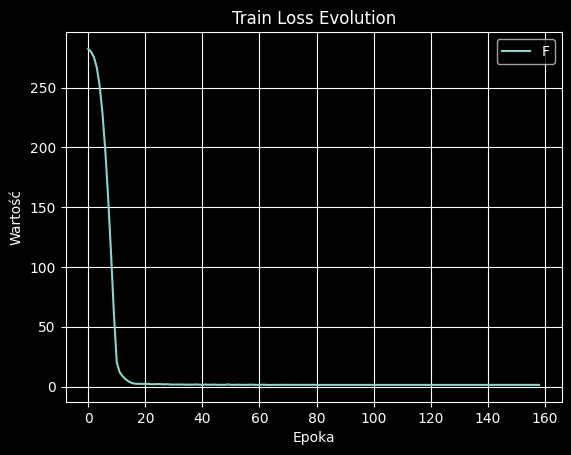



EXPERIMENT: temperature_regression_encoding
TASK: REGRESSION
CONFIGURATION (variable params):
  WEATHER:
    - window_aggregation: flatten
    - input_variables: ('temperature', 'humidity')
    - aggregations: {'temperature': ('mean', 'min', 'max'), 'humidity': ('mean', 'min', 'max'), 'pressure': ('mean', 'min', 'max'), 'wind_speed': ('mean', 'max'), 'wind_direction': ('mean',)}
    - normalization: standardize
  MLP:
    - hidden_layers: (32, 64)
    - loss: huber
    - activation: gelu
--------------------------------------------------------------------------------
=== TEST METRICS (REGRESSION) ===
MAE              : 2.0968
MSE              : 7.5904
RMSE             : 2.7551
Accuracy |err|≤2°C   : 0.5793
Accuracy |err|≤2.5°C : 0.6677


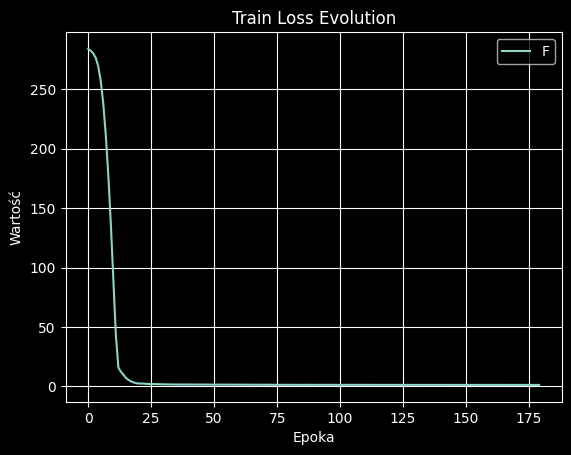



EXPERIMENT: temperature_regression_encoding
TASK: REGRESSION
CONFIGURATION (variable params):
  WEATHER:
    - window_aggregation: flatten
    - input_variables: ('temperature', 'humidity')
    - aggregations: {'temperature': ('mean', 'min', 'max', 'trend'), 'humidity': ('mean', 'min', 'max', 'trend'), 'pressure': ('mean', 'min', 'max', 'trend'), 'wind_speed': ('mean', 'max'), 'wind_direction': ('mean',)}
    - normalization: standardize
  MLP:
    - hidden_layers: (32, 64)
    - loss: huber
    - activation: gelu
--------------------------------------------------------------------------------
=== TEST METRICS (REGRESSION) ===
MAE              : 2.2170
MSE              : 10.0549
RMSE             : 3.1709
Accuracy |err|≤2°C   : 0.6067
Accuracy |err|≤2.5°C : 0.6860


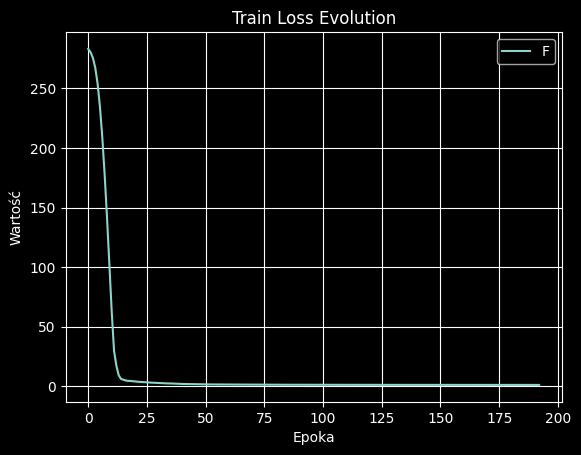

In [5]:
for run in results:
    model = run["model"]
    y_test = run["y_test"]
    y_pred = run["y_pred"]
    y_proba = run["y_proba"]

    history = run["history"]
    accuracy_history = run["accuracy_history"]
    config_log = run.get("config_log", {})

    print("\n\n" + "=" * 80)
    print(f"EXPERIMENT: {run['experiment']}")
    print(f"TASK: {model.task.upper()}")
    print("=" * 80)

    # ========= CONFIGURATION (VARIABLE PARAMS) =========
    if config_log:
        print("CONFIGURATION (variable params):")
        for section, params in config_log.items():
            if not params:
                continue
            print(f"  {section.upper()}:")
            for k, v in params.items():
                print(f"    - {k}: {v}")
        print("-" * 80)

    # ===================== METRICS =====================
    if model.task == "binary":
        metrics = classification_report_binary(
            y_true=y_test,
            y_score=y_proba,
            threshold=0.5,
        )

        print("=== TEST METRICS (BINARY CLASSIFICATION) ===")
        print(f"Accuracy : {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall   : {metrics['recall']:.4f}")
        print(f"AUC      : {metrics['auc']:.4f}")

    else:
        metrics = regression_report(
            y_true=y_test,
            y_pred=y_pred,
        )

        acc_2 = accuracy_within_tolerance(y_test, y_pred, tol=2.0)
        acc_25 = accuracy_within_tolerance(y_test, y_pred, tol=2.5)

        print("=== TEST METRICS (REGRESSION) ===")
        print(f"MAE              : {metrics['mae']:.4f}")
        print(f"MSE              : {metrics['mse']:.4f}")
        print(f"RMSE             : {metrics['rmse']:.4f}")
        print(f"Accuracy |err|≤2°C   : {acc_2:.4f}")
        print(f"Accuracy |err|≤2.5°C : {acc_25:.4f}")

    # --- plots ---
    plot_loss(
        history,
        title="Train Loss Evolution",
    )

    if model.task != "regression":
        if accuracy_history and not all(np.isnan(accuracy_history)):
            plot_accuracy(
                accuracy_history,
                title="Accuracy evolution",
            )

    # ROC only for binary classification
    if model.task == "binary":
        plot_roc_auc(
            y_true=y_test,
            y_score=y_proba,
            title="ROC Curve",
        )
